In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency
from scipy.stats.contingency import association

In [2]:
df = pd.read_csv('Dog Bite Dataset.csv', header=0)
print(df.head())

   UniqueID       DateOfBite Species        Breed  Age Gender  SpayNeuter  \
0         1  January 01 2018     DOG      UNKNOWN  NaN      U       False   
1         2  January 04 2018     DOG      UNKNOWN  NaN      U       False   
2         3  January 06 2018     DOG     Pit Bull  NaN      U       False   
3         4  January 08 2018     DOG  Mixed/Other    4      M       False   
4         5  January 09 2018     DOG     Pit Bull  NaN      U       False   

    Borough ZipCode  
0  Brooklyn   11220  
1  Brooklyn     NaN  
2  Brooklyn   11224  
3  Brooklyn   11231  
4  Brooklyn   11224  


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34033 entries, 0 to 34032
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   UniqueID    34033 non-null  int64 
 1   DateOfBite  34033 non-null  object
 2   Species     34033 non-null  object
 3   Breed       31756 non-null  object
 4   Age         16068 non-null  object
 5   Gender      34033 non-null  object
 6   SpayNeuter  34033 non-null  bool  
 7   Borough     34033 non-null  object
 8   ZipCode     23450 non-null  object
dtypes: bool(1), int64(1), object(7)
memory usage: 2.1+ MB


In [4]:
#Identifying Duplicates
duplicates = df.duplicated().sum()
print(duplicates)

0


In [5]:
#Identifying Missing Values
df.isna().sum()

UniqueID          0
DateOfBite        0
Species           0
Breed          2277
Age           17965
Gender            0
SpayNeuter        0
Borough           0
ZipCode       10583
dtype: int64

In [6]:
#Replacing Missing Values & Blanks with NaN/Unknown
df['ZipCode'] = df['ZipCode'].replace(['','N/A', '?'], np.nan)
df['Breed'] = df['Breed'].replace(['','N/A'], np.nan)
df['Breed'] = df['Breed'].fillna('Unknown')
df['Age'] = df['Age'].fillna('Unknown')

print(df.isna().sum())

UniqueID          0
DateOfBite        0
Species           0
Breed             0
Age               0
Gender            0
SpayNeuter        0
Borough           0
ZipCode       10584
dtype: int64


In [7]:
#Identifying Formatting Errors
object_cols = ['DateOfBite', 'Species', 'Breed', 'Age', 'Gender', 'SpayNeuter', 'Borough', 'ZipCode']
df[object_cols].nunique()

DateOfBite    3650
Species          1
Breed         2076
Age            238
Gender           3
SpayNeuter       2
Borough          6
ZipCode        628
dtype: int64

In [8]:
df['Borough'].value_counts()

Borough
Queens           8652
Manhattan        7694
Brooklyn         7317
Bronx            6025
Staten Island    2863
Other            1482
Name: count, dtype: int64

In [9]:
df['ZipCode'].unique()

array(['11220', nan, '11224', '11231', '11233', '11235', '11208', '11215',
       '11238', '11207', '11205', '11209', '11237', '11217', '11236',
       '11234', '11214', '11230', '11211', '11225', '11210', '11223',
       '11232', '11226', '11201', '11212', '11216', '11239', '11219',
       '11218', '11206', '11229', '11222', '11203', '11204', '11221',
       '11249', '11213', '112', '11228', '111208', '112238', '1122',
       '112006', '10473', '10456', '10454', '10460', '10459', '10468',
       '10465', '10462', '10466', '10472', '10470', '10461', '10471',
       '10451', '10467', '10458', '10455', '10464', '10453', '10475',
       '10457', '10452', '10469', '10463', '10474', '100467', '10482',
       '104', '10987', '10549', '466', '10495', '10039', '10421', '10065',
       '10010', '10031', '10029', '10026', '10016', '10003', '10032',
       '10128', '10001', '10022', '10021', '10040', '10023', '10011',
       '10027', '10024', '10034', '10013', '10009', '10025', '10004',
       '1

In [10]:
df['ZipCode'] = df['ZipCode'].replace('O', '0', regex = False)
df['ZipCode'] = pd.to_numeric(df['ZipCode'], errors = 'coerce').astype('Int64')

print(df['ZipCode'].head())

0    11220
1     <NA>
2    11224
3    11231
4    11224
Name: ZipCode, dtype: Int64


In [11]:
df['DateOfBite'] = pd.to_datetime(df['DateOfBite'], dayfirst = False, yearfirst = False)

print(df['DateOfBite'].head())

0   2018-01-01
1   2018-01-04
2   2018-01-06
3   2018-01-08
4   2018-01-09
Name: DateOfBite, dtype: datetime64[ns]


In [12]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 34033 entries, 0 to 34032
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   UniqueID    34033 non-null  int64         
 1   DateOfBite  34033 non-null  datetime64[ns]
 2   Species     34033 non-null  object        
 3   Breed       34033 non-null  object        
 4   Age         34033 non-null  object        
 5   Gender      34033 non-null  object        
 6   SpayNeuter  34033 non-null  bool          
 7   Borough     34033 non-null  object        
 8   ZipCode     23447 non-null  Int64         
dtypes: Int64(1), bool(1), datetime64[ns](1), int64(1), object(5)
memory usage: 2.1+ MB


In [29]:
df.to_csv('Cleaned Dog Bite Dataset.csv', index = False)

In [13]:
#Descriptive Statistics for Qualitative Variables
qualitative_cols = ['Breed', 'Gender', 'SpayNeuter', 'Borough']

for col in qualitative_cols:
    print((df[col].value_counts(normalize = True) * 100).round(2).sort_values(ascending = False))

Breed
UNKNOWN                 18.08
Pit Bull                17.20
Unknown                  6.69
Shih Tzu                 2.79
German Shepherd          2.76
                        ...  
OLDE ENGLISH BULLDOG     0.00
WESTIEPOO                0.00
CHORKIE MIX              0.00
WEST HIGHLAND            0.00
SHIH TZU / PEKINGESE     0.00
Name: proportion, Length: 2076, dtype: float64
Gender
U    49.74
M    36.26
F    14.00
Name: proportion, dtype: float64
SpayNeuter
False    77.46
True     22.54
Name: proportion, dtype: float64
Borough
Queens           25.42
Manhattan        22.61
Brooklyn         21.50
Bronx            17.70
Staten Island     8.41
Other             4.35
Name: proportion, dtype: float64


Text(0.5, 1.0, 'Dog Bites by Borough')

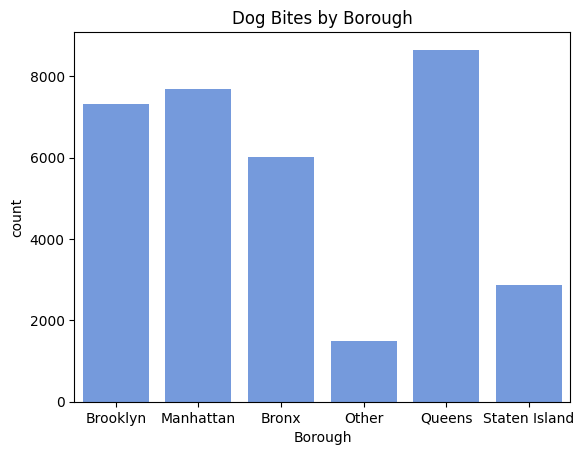

In [19]:
#Univariate Visualizations
sns.countplot(x=df['Borough'], color = 'cornflowerblue')
plt.title('Dog Bites by Borough')

Text(0.5, 1.0, 'Dog Bites by Gender')

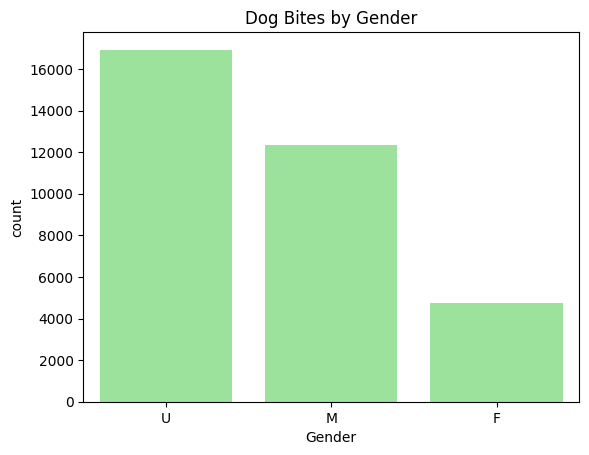

In [15]:
sns.countplot(x=df['Gender'], color = 'lightgreen')
plt.title('Dog Bites by Gender')

Text(0.5, 1.0, 'Dog Spay/Neuter Status')

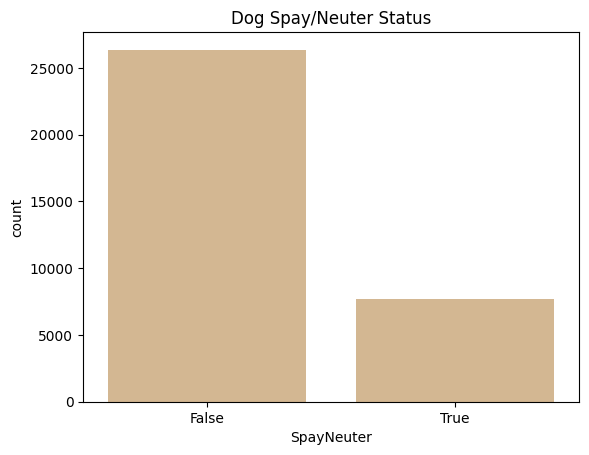

In [16]:
sns.countplot(x=df['SpayNeuter'], color='burlywood')
plt.title('Dog Spay/Neuter Status')

Text(0.5, 1.0, 'Dog Spay/Neuter Status by Gender')

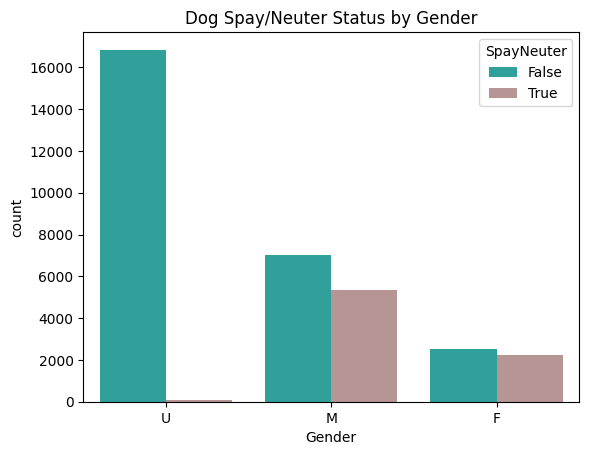

In [17]:
#Bivariate Visualizations
sns.countplot(x=df['Gender'], hue=df['SpayNeuter'], palette=['lightseagreen', 'rosybrown'])
plt.title('Dog Spay/Neuter Status by Gender')

Text(0.5, 1.0, 'Dog Spay/Neuter Status by Borough')

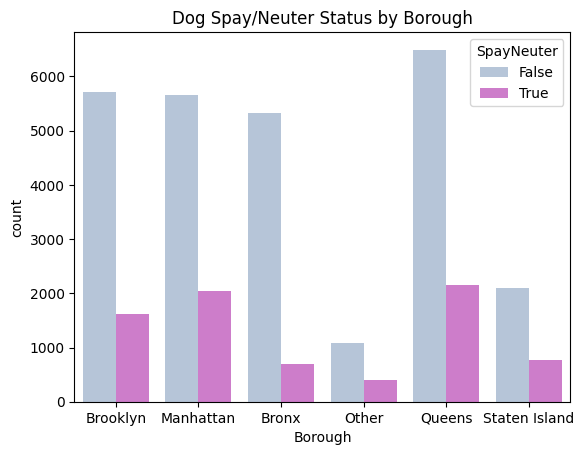

In [18]:
sns.countplot(x=df['Borough'], hue=df['SpayNeuter'], palette=['lightsteelblue', 'orchid'])
plt.title('Dog Spay/Neuter Status by Borough')

In [28]:
#Chi-Square Test 1
df_gender = df[df['Gender'] != 'U']
contingency_table1 = pd.crosstab(df_gender['Gender'], df_gender['SpayNeuter'])
print('Contingency Table 1: ')
print(contingency_table1)

#Performing Test
chi2_stat1, p_value1, dof_1, expected_1 = chi2_contingency(contingency_table1)

#Displaying Results
print(f'\nChi-Square Statistic : {chi2_stat1:.4f}')
print(f'Degrees of Freedom: {dof_1}')
print('Expected Frequencies Table:\n', expected_1)
print(f'P-value: {p_value1:.4f}')

Contingency Table 1: 
SpayNeuter  False  True 
Gender                  
F            2506   2259
M            7016   5325

Chi-Square Statistic : 25.0985
Degrees of Freedom: 1
Expected Frequencies Table:
 [[2652.42195721 2112.57804279]
 [6869.57804279 5471.42195721]]
P-value: 0.0000


In [22]:
#Calculating Cramer's V
value_1 = association(contingency_table1, method='cramer')
print(f'Cramer\'s V: {value_1}')

Cramer's V: 0.038435700096691935


In [23]:
#Interpreting Results
if p_value1 < 0.05:
    print('Reject the Null Hypothesis')
else:
    print('Failed to Reject the Null Hypothesis')

Reject the Null Hypothesis


In [25]:
# Chi-Square Test 2
df_borough = df[df['Borough'] != 'Other']
contingency_table2 = pd.crosstab(df_borough['Borough'], df_borough['SpayNeuter'])
print('Contingency Table: ')
print(contingency_table2)

#Performing Test
chi2_stat2, p_value2, dof_2, expected_2 = chi2_contingency(contingency_table2)

#Displaying Results
print(f'\nChi-Square Statistic : {chi2_stat2:.4f}')
print(f'Degrees of Freedom: {dof_2}')
print('Expected Frequencies Table:\n', expected_2)
print(f'P-value: {p_value2:.4f}')

Contingency Table: 
SpayNeuter     False  True 
Borough                    
Bronx           5331    694
Brooklyn        5707   1610
Manhattan       5661   2033
Queens          6492   2160
Staten Island   2089    774

Chi-Square Statistic : 551.8708
Degrees of Freedom: 4
Expected Frequencies Table:
 [[4679.18036312 1345.81963688]
 [5682.58302356 1634.41697644]
 [5975.37157077 1718.62842923]
 [6719.38066419 1932.61933581]
 [2223.48437836  639.51562164]]
P-value: 0.0000


In [26]:
#Calculating Cramer's V
value_2 = association(contingency_table2, method='cramer')
print(f'Cramer\'s V: {value_2}')

Cramer's V: 0.13020765878527785


In [27]:
#Interpreting Results
if p_value2 < 0.05:
    print('Reject the Null Hypothesis')
else:
    print('Failed to Reject the Null Hypothesis')

Reject the Null Hypothesis
